In [9]:
import numpy as np
from matplotlib import pyplot as plt
from echospec.utils.parameters import Parameters
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy, OptionsSpectroscopy2d
from echospec.utils.units import Units as u

Amplitude sweep:   0%|          | 0/11 [00:00<?, ?Ω/s]

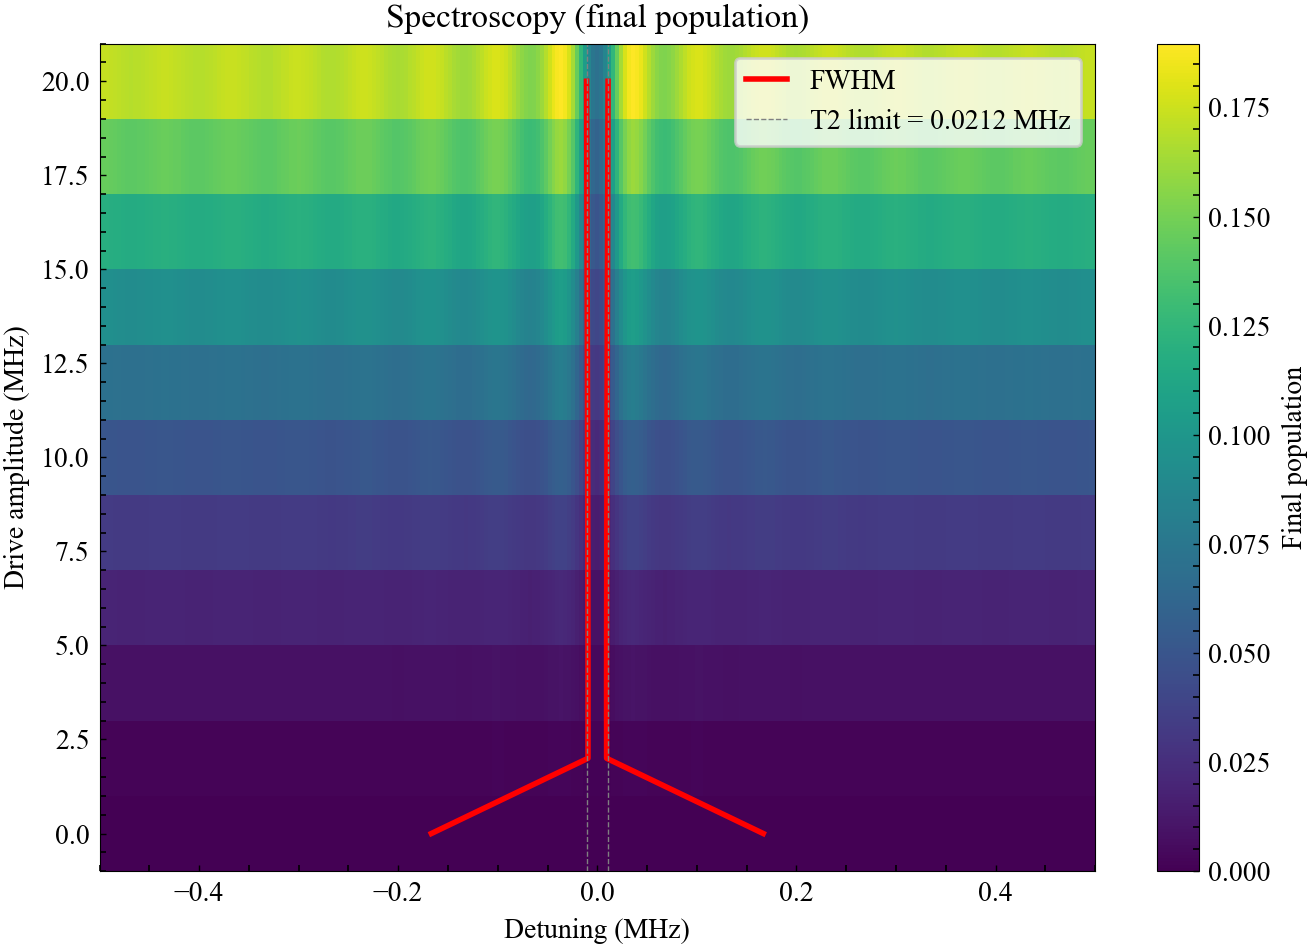

In [10]:
options = OptionsSpectroscopy2d(plot=True)
options.num_time_points = 2000
params = Parameters()
params.eco_pulse = True
params.pulse_length = 30*u.us
params.cutoff = 2e-4
# params.rabi_frequency = 10*u.MHz*2*np.pi
# params.detuning = 0.1*u.MHz*2*np.pi


detunings = np.linspace(-0.5, 0.5, 251)*2*np.pi*u.MHz
amplitudes = np.linspace(0, 20, 11)*2*np.pi*u.MHz
spectroscopy = AmplitudeSweepSpectroscopy(
    amplitudes=amplitudes,
    detunings=detunings,
    params=params,
    options=options
)

results = spectroscopy.run()

In [11]:
ts = results.spectroscopies[0].time  # in us
detunings = results.detunings
amplitudes = results.amplitudes
final_z = results.final_map()

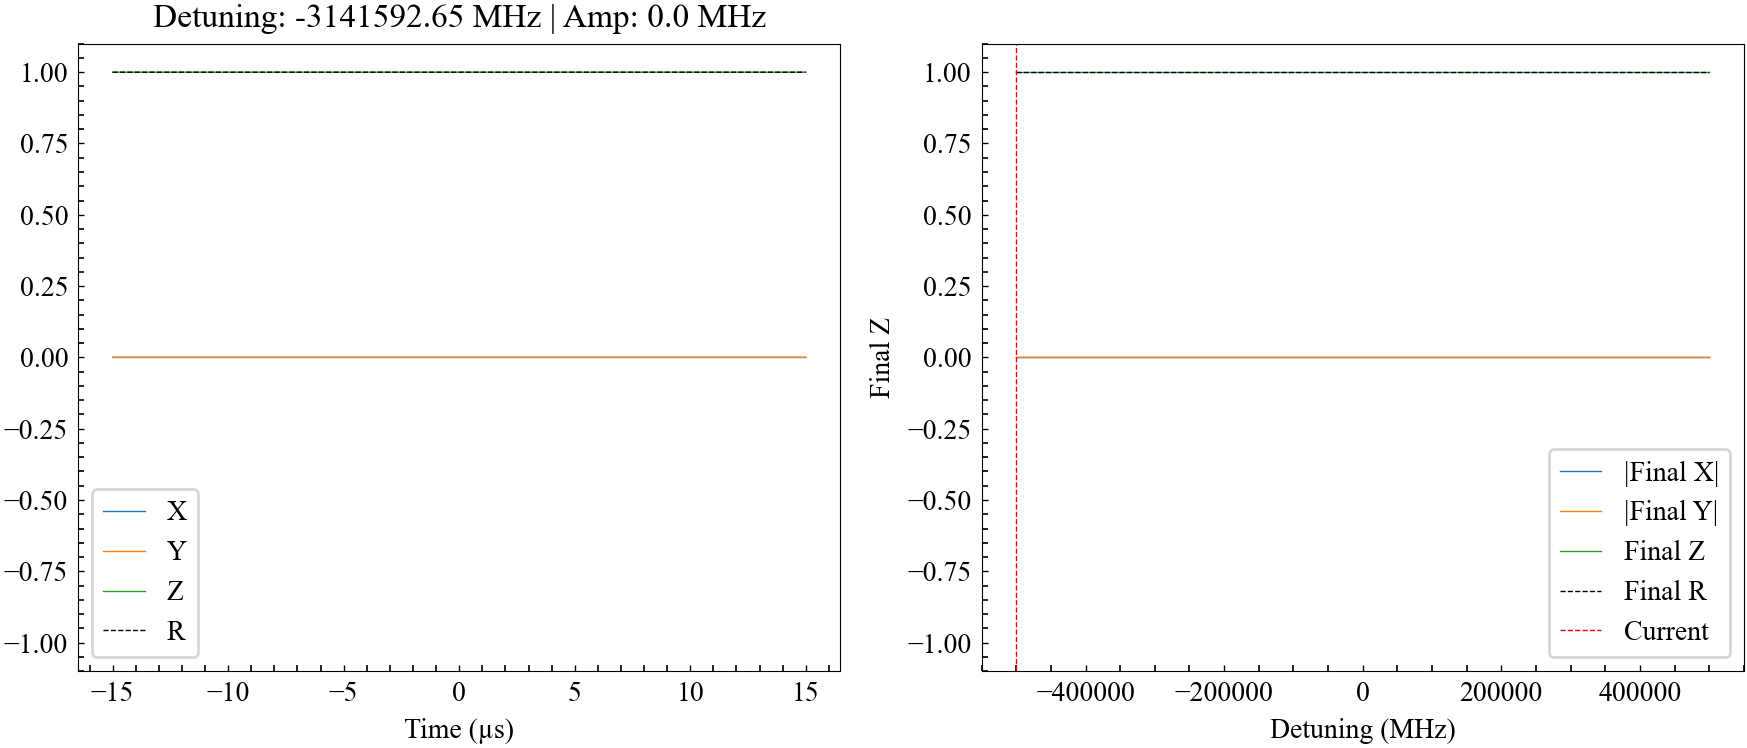

interactive(children=(IntSlider(value=0, description='Detuning', max=250), IntSlider(value=0, description='Amp…

<function __main__.update(detuning_index, amplitude_index) -> None>

In [12]:
# %matplotlib ipympl
from ipywidgets import interact, IntSlider

fig, axs = plt.subplots(1, 2, figsize=(9, 4))

det_idx0 = 0
amp_idx0 = 0

raw_data = results.raw_data()

x0 = raw_data[:, 0, :, :][det_idx0][amp_idx0]
y0 = raw_data[:, 1, :, :][det_idx0][amp_idx0]
z0 = raw_data[:, 2, :, :][det_idx0][amp_idx0]


r0 = np.sqrt(x0**2 + y0**2 + z0**2)

ax = axs[0]
(line_x,) = ax.plot(ts * 1e6, x0, label="X")
(line_y,) = ax.plot(ts * 1e6, y0, label="Y")
(line_z,) = ax.plot(ts * 1e6, z0, label="Z")
(line_r,) = ax.plot(ts * 1e6, r0, "--", color="black", label="R")

ax.set_xlabel("Time (µs)")
ax.legend()
ax.set_ylim(-1.1, 1.1)
title = ax.set_title(
    f"Detuning: {detunings[det_idx0]:.2f} MHz | Amp: {amplitudes[amp_idx0]:.1f} MHz")

# final Z at end of pulse
final_x = results.final_map(observable="x")
final_y = results.final_map(observable="y")
final_z = results.final_map()

final_r = np.sqrt(final_x**2 + final_y**2 + final_z**2)

ax2 = axs[1]
(spec_line_x,) = ax2.plot(detunings/2/np.pi,
                          np.abs(final_x[amp_idx0]), label="|Final X|")
(spec_line_y,) = ax2.plot(detunings/2/np.pi,
                          np.abs(final_y[amp_idx0]), label="|Final Y|")
(spec_line_z,) = ax2.plot(detunings/2 /
                          np.pi, final_z[amp_idx0], label="Final Z")
(spec_line_r,) = ax2.plot(detunings/2/np.pi,
                          final_r[amp_idx0], "--", color="black", label="Final R")

vline = ax2.axvline(detunings[det_idx0]/2/np.pi,
                    color="red", linestyle="--", label="Current")
ax2.set_xlabel(r"Drive detuning $(f_d-f_{01})$ (MHz)")
ax2.set_ylabel("Final Z")
ax2.legend()
ax2.set_ylim(-1.1, 1.1)

fig.tight_layout()
fig.canvas.draw_idle()


def update(detuning_index, amplitude_index) -> None:
    x = raw_data[:, 0, :, :][amplitude_index][detuning_index]
    y = raw_data[:, 1, :, :][amplitude_index][detuning_index]
    z = raw_data[:, 2, :, :][amplitude_index][detuning_index]

    r = np.sqrt(x**2 + y**2 + z**2)

    line_x.set_ydata(x)
    line_y.set_ydata(y)
    line_z.set_ydata(z)
    line_r.set_ydata(r)

    title.set_text(
        f"Detuning: {detunings[detuning_index]/1e6/2/np.pi:.2f} MHz | Amp: {amplitudes[amplitude_index]:.1f} MHz"
    )

    spec_line_x.set_ydata(final_x[amplitude_index])
    spec_line_y.set_ydata(final_y[amplitude_index])
    spec_line_z.set_ydata(final_z[amplitude_index])
    spec_line_r.set_ydata(final_r[amplitude_index])
    vline.set_xdata([detunings[detuning_index]/2/np.pi])

    # fig.canvas.draw_idle()


interact(
    update,
    detuning_index=IntSlider(min=0, max=len(
        detunings) - 1, step=1, value=det_idx0, description="Detuning"),
    amplitude_index=IntSlider(min=0, max=len(
        amplitudes) - 1, step=1, value=amp_idx0, description="Amplitude"),
)

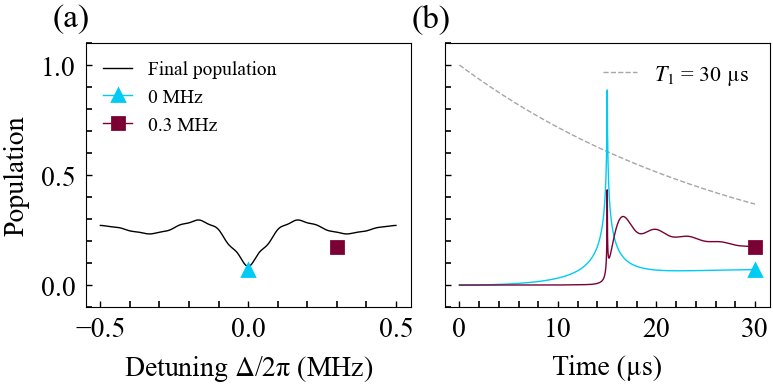

In [13]:
from echospec.simulation.pulses import PulseArgs, echo_lorentzian_envelope
from echospec.utils.parameters import Parameters
from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
AMP_IDX = -1
STATE_IDX = 1200
TARGET_DET = 0.3 * 2*np.pi * u.MHz
T1_US = 30

MHz = 2*np.pi*1e6


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def z_to_population(z):
    """Map Bloch-Z → excited-state population."""
    return 0.5 * (1 - z)


def detuning_to_mhz(det):
    return det / MHz


def extract_z(data, amp_idx):
    """Extract Z component for selected amplitude."""
    return data[:, 2, :, :][amp_idx]


# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------
z_data = extract_z(raw_data, AMP_IDX)

det_zero_idx = np.argmin(np.abs(detunings))
det_nonzero_idx = np.argmin(np.abs(detunings - TARGET_DET))

z_spec = z_data[:, STATE_IDX]
z_zero = z_data[det_zero_idx]
z_off = z_data[det_nonzero_idx]

ts_us = (ts + ts[-1]) * 1e6


T2_limit = Parameters().T2_limit/1e6

# ------------------------------------------------------------
# Figure

# ------------------------------------------------------------
fig, (ax_spec, ax_time) = plt.subplots(
    1, 2,
    figsize=(4.2, 2),
    # gridspec_kw={"height_ratios": [1, 1.7]}  # <-- upper shorter,
    sharey=True
)
color1 = "#00cbf4"  # Green
color2 = "#7b0134"  # Red


# ---------------- Spectroscopy ----------------
ax_spec.plot(
    detuning_to_mhz(detunings),
    z_to_population(z_spec),
    color="black",
    label="Final population",
)

# ax_spec.axvline(
#     detuning_to_mhz(detunings[det_zero_idx]),
#     color=color1, linestyle=":", label="0 MHz"
# )

ax_spec.plot(
    detuning_to_mhz(detunings[det_zero_idx]),
    z_to_population(z_zero)[-1],
    marker="^", color=color1, label="0 MHz", markersize=4
)

ax_spec.plot(
    detuning_to_mhz(detunings[det_nonzero_idx]),
    z_to_population(z_off)[-1],
    marker="s", color=color2, label="0.3 MHz", markersize=4
)


# ax_spec.axvline(T2_limit/2, color="gray", linestyle="--", label=f"T2 limit ({T2_limit:.1f} MHz)")
# ax_spec.axvline(-T2_limit/2, color="gray", linestyle="--")


# ax_spec.axvline(
#     detuning_to_mhz(detunings[det_nonzero_idx]),
#     color=color2, linestyle=":",
#     label=f"{detuning_to_mhz(detunings[det_nonzero_idx]):.1f} MHz"
# )

ax_spec.set(
    xlabel=r"Drive detuning $(f_d-f_{01})$ (MHz)",
    ylabel="Population",
    ylim=(0, 0.7),
)


# ---------------- Time Evolution ----------------


pulse_args = PulseArgs(
    cutoff=params.cutoff,
    pulse_length=params.pulse_length,
)
env = echo_lorentzian_envelope(ts, args=pulse_args)*50
# ax_time.plot(
#     ts_us,
#     env + 0.5,
#     ":", color="purple", alpha=1,
#     label="Echo-Lorentzian\n envelope",
#     linewidth=1.5,

# )
# T1 decay
ax_time.plot(
    ts_us,
    np.exp(-ts_us/T1_US),
    "--", color="gray", alpha=0.7,
    label=f"$T_1$ = {T1_US} µs"
)

ax_time.plot(
    ts_us,
    z_to_population(z_zero),
    color=color1,
    linestyle='-',

)

ax_time.plot(
    ts_us,
    z_to_population(z_off),
    color=color2,
    linestyle='-',
)

ax_time.plot(
    30,
    z_to_population(z_zero)[-1],
    marker="^",
    color=color1,
    markersize=4
)

ax_time.plot(
    30,
    z_to_population(z_off)[-1],
    marker="s", color=color2, markersize=4
)


# ---------------- Echo-Lorentzian envelope ----------------


ax_time.set(
    xlabel="Time (µs)",
    # ylabel="Population",
)

ax_time.set_ylim(-0.1, 1.1)
ax_time.set_xticks([0, 10, 20, 30])


# ------------------------------------------------------------
# Final styling
# ------------------------------------------------------------
for ax in (ax_spec, ax_time):
    ax.grid(False)

ax_spec.legend(frameon=False, loc="upper left", fontsize=7)
ax_time.legend(frameon=False, loc="upper right", fontsize=8)

fig.tight_layout()
ax_spec.text(-0.1, 1.15, "(a)", transform=ax_spec.transAxes,
             fontsize="large",  va="top")
ax_time.text(-0.1, 1.15, "(b)", transform=ax_time.transAxes,
             fontsize="large",  va="top")

save_figure(fig, "spectroscopy_and_evolution", variant=VARIANT, formats=("png",))
plt.show()

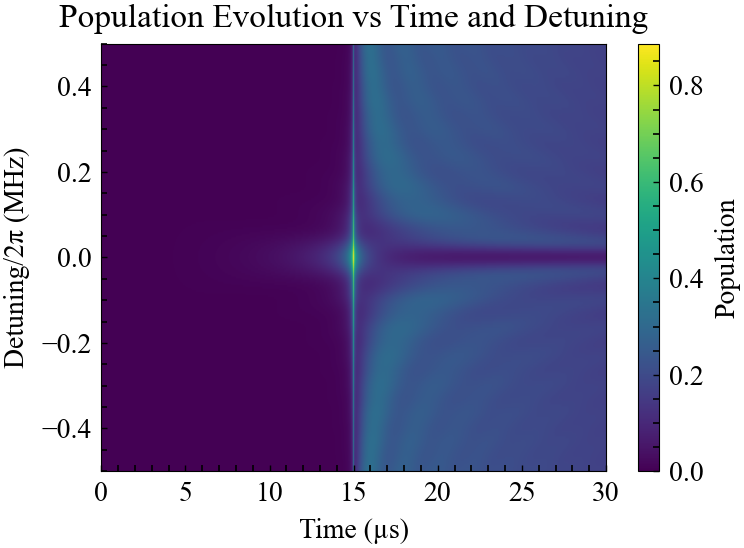

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))
apply_figure_style(VARIANT)

# Create waterfall plot using z_data (detuning vs time)
# z_data shape is (251, 2000) - 251 detunings, 2000 time points
# Convert to population for better visualization

# z_data = results['z_data']

z_data = extract_z(raw_data, AMP_IDX)

population_data = z_to_population(z_data)

# Create the waterfall plot
im = ax.imshow(
    population_data,
    aspect='auto',
    extent=[ts_us[0], ts_us[-1],
            detuning_to_mhz(detunings[0]), detuning_to_mhz(detunings[-1])],
    origin='lower',
    cmap='viridis'
)

ax.set_xlabel('Time (µs)')
ax.set_ylabel(r'Drive detuning $(f_d-f_{01})$ (MHz)')
ax.set_title('Population Evolution vs Time and Detuning')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, label='Population')

fig.tight_layout()
plt.show()

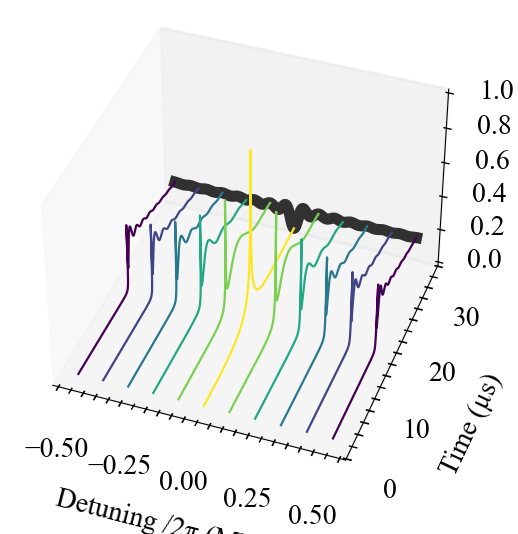

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')

time = ts_us
det = detuning_to_mhz(detunings)
Z = population_data   # shape: (Ndet, Nt)

# choose 10 evenly spaced detuning indices
idx = np.linspace(0, len(det)-1, 11).astype(int)

t_final = time[-1]

# spectroscopy slice at final time
Z_spec = Z[:, -1] / Z.max()

fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

# plot as ridge at final time
ax.plot(
    det,                          # x → detuning
    np.ones_like(det)*t_final,    # y → fixed final time
    Z_spec,                       # z → population
    color='black',
    lw=4,
    label='spectroscopy',
    alpha=0.8
)

for i in idx:

    # x = time
    x = time

    # y = detuning (constant offset)
    y = np.ones_like(time) * det[i]

    # z = population vs time

    z = Z[i] / Z.max()     # normalize optional

    color = plt.cm.viridis_r(abs(det[i])/det.max())

    ax.plot(y, x, z, lw=0.8, color=color)


ax.set_ylabel('Time (µs)')
ax.set_xlabel(r'Drive detuning $(f_d-f_{01})$ (MHz)')
ax.set_zlabel('Population')

ax.view_init(elev=40, azim=-70)

# make it not look like MATLAB 2004
ax.grid(False)
# ax.xaxis.pane.fill = False

# ax.zaxis.pane.fill = False

# plt.tight_layout()
save_figure(plt.gcf(), "waterfall_3d", variant=VARIANT, formats=("png",))
plt.show()

/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_1829/2875024150.py:14: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_1829/2875024150.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_1829/2875024150.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


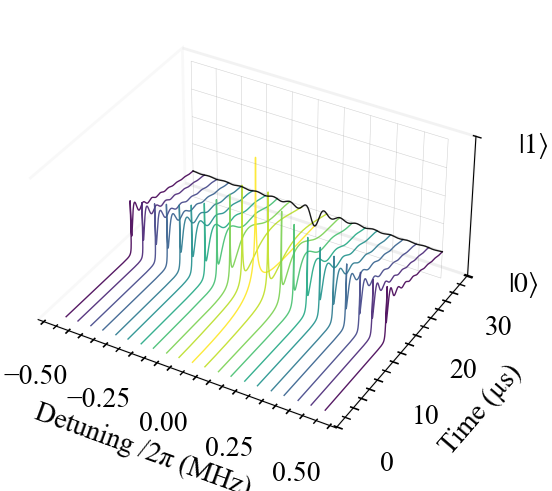

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(3.2, 3.0), dpi=200, constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

time = ts_us
det = detuning_to_mhz(detunings)
Z = population_data

idx = np.linspace(0, len(det)-1, 21).astype(int)


fig.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.10,
    top=0.95
)

T1 = params.T1/1e6

t_final = time[-1]
Z_spec = Z[:, -1] / Z.max()

# ----- style -----
cmap = plt.cm.viridis
norm = plt.Normalize(det.min(), det.max())

# spectroscopy ridge
ax.plot(
    det,
    np.ones_like(det)*t_final,
    Z_spec,
    color='black',
    lw=0.5,
    alpha=0.9,
    zorder=5
)

# waterfall lines
for i in idx:

    x = time
    y = np.ones_like(time) * det[i]
    z = Z[i] / Z.max()

    color = plt.cm.viridis_r(abs(det[i])/det.max())

    ax.plot(
        y,
        x,
        z,
        lw=0.5,
        color=color,
        alpha=0.9
    )

# ----- axes -----
ax.set_xlabel(r'Drive detuning $(f_d-f_{01})$ (MHz)', labelpad=2)
ax.set_ylabel('Time (µs)', labelpad=1)
# ax.set_zlabel('Population', labelpad=-3)

ax.set_zlim(0, 1)

# nicer camera angle
ax.view_init(elev=35, azim=-60,)

# remove ugly panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    # axis.pane.set_edgecolor('white')

# lighter grid
ax.grid(False)

# ticks
# ax.tick_params(axis='both', which='major', labelsize=8)
# ax.tick_params(axis='z', labelsize=8)

# aspect
ax.set_box_aspect((1.2, 1, 0.6))
# Set z-axis ticks to show quantum states
ax.set_zticks([0, 1])
ax.set_zticklabels([r'$|0\rangle$', r'$|1\rangle$'])


plt.tight_layout()


# grid on the plane y = t_final
xg = np.linspace(det.min(), det.max(), 80)
zg = np.linspace(0, 1, 6)
Xg, Zg = np.meshgrid(xg, zg)
Yg = np.full_like(Xg, t_final)

ax.plot_wireframe(
    Xg, Yg, Zg,
    color="gray",
    linewidth=0.2,
    alpha=0.35,
    rstride=1,
    cstride=8
)

save_figure(plt.gcf(), "waterfall_3d", variant=VARIANT, formats=("png",))
# plt.tight_layout(